# Imports and environment setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.ticker import FixedLocator

%matplotlib inline

BASE_DATA_DIR = "/path/to/data"
BASE_RESULT_DIR = "/path/to/results"

CACHE_DIR = os.path.join(BASE_RESULT_DIR, "cache_cosine")
SAVE_DIR  = os.path.join(BASE_RESULT_DIR, "plots/section4")
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

DNV_PATH  = "/path/to/data/variant_info.feather"
KEYS_FP   = os.path.join(BASE_RESULT_DIR, "cosine_keys.feather")
MERGED_FP = os.path.join(SAVE_DIR, "merged_cosine_delta_final.feather")

MODELS = ["dnabert", "dnabert2", "ntv2", "ntv3", "evo2", "hyenadna", "phylogpn"]
TASKS  = ["clinvar", "gnomad", "bend", "ncre"]

MODEL_LABEL = {
    "dnabert": "DNABERT", "dnabert2": "DNABERT-2",
    "ntv2": "Nucleotide\nTransformer V2", "ntv3": "Nucleotide\nTransformer V3",
    "evo2": "Evo 2", "hyenadna": "HyenaDNA", "phylogpn": "PhyloGPN"
}

TASK_TITLE = {
    "clinvar": "ClinVar Missense", "gnomad": "gnomAD",
    "bend": "BEND Non-coding", "ncre": "Regulatory Elements"
}

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "axes.linewidth": 1.0, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "font.size": 12
})

def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    n, m = len(a), len(b)
    if n < 2 or m < 2: return np.nan
    if n * m > 1e6:
        rng = np.random.default_rng(0)
        a = rng.choice(a, size=min(n, 2000), replace=False)
        b = rng.choice(b, size=min(m, 2000), replace=False)
    gt = np.sum(a[:, None] > b[None, :])
    lt = np.sum(a[:, None] < b[None, :])
    return float((gt - lt) / (len(a) * len(b)))

def p_to_star(p):
    if not np.isfinite(p) or p >= 0.05: return "n.s."
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    return "*"

def add_sig_bracket(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color="black", clip_on=False)
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom" if h > 0 else "top", 
            fontsize=13, fontweight="bold")

# Extract and save cosine similarity per model

In [ ]:
def to_2d(series):
    return np.stack([np.asarray(x, dtype=np.float32) for x in series.to_list()], axis=0)

def compute_cosine_and_cache():
    for m in MODELS:
        for t in TASKS:
            zero_path = os.path.join(BASE_DATA_DIR, f"{m}_{t}_zero_raw.feather")
            ft_path   = os.path.join(BASE_DATA_DIR, f"{m}_{t}_ft_raw.feather")
            
            if not (os.path.exists(zero_path) and os.path.exists(ft_path)):
                continue
                
            df_z = pd.read_feather(zero_path)
            df_f = pd.read_feather(ft_path)
            
            emb_z_ref = to_2d(df_z["ref_emb"])
            emb_z_var = to_2d(df_z["var_emb"])
            emb_f_ref = to_2d(df_f["ref_emb"])
            emb_f_var = to_2d(df_f["var_emb"])
            
            def get_sim(a, b):
                na = np.linalg.norm(a, axis=1, keepdims=True)
                nb = np.linalg.norm(b, axis=1, keepdims=True)
                return np.sum((a/na) * (b/nb), axis=1)

            sim_z = get_sim(emb_z_ref, emb_z_var)
            sim_f = get_sim(emb_f_ref, emb_f_var)
            
            np.save(os.path.join(CACHE_DIR, f"{m}__{t}__zero.npy"), sim_z)
            np.save(os.path.join(CACHE_DIR, f"{m}__{t}__ft.npy"), sim_f)

compute_cosine_and_cache()

# Visualize similarity distribution

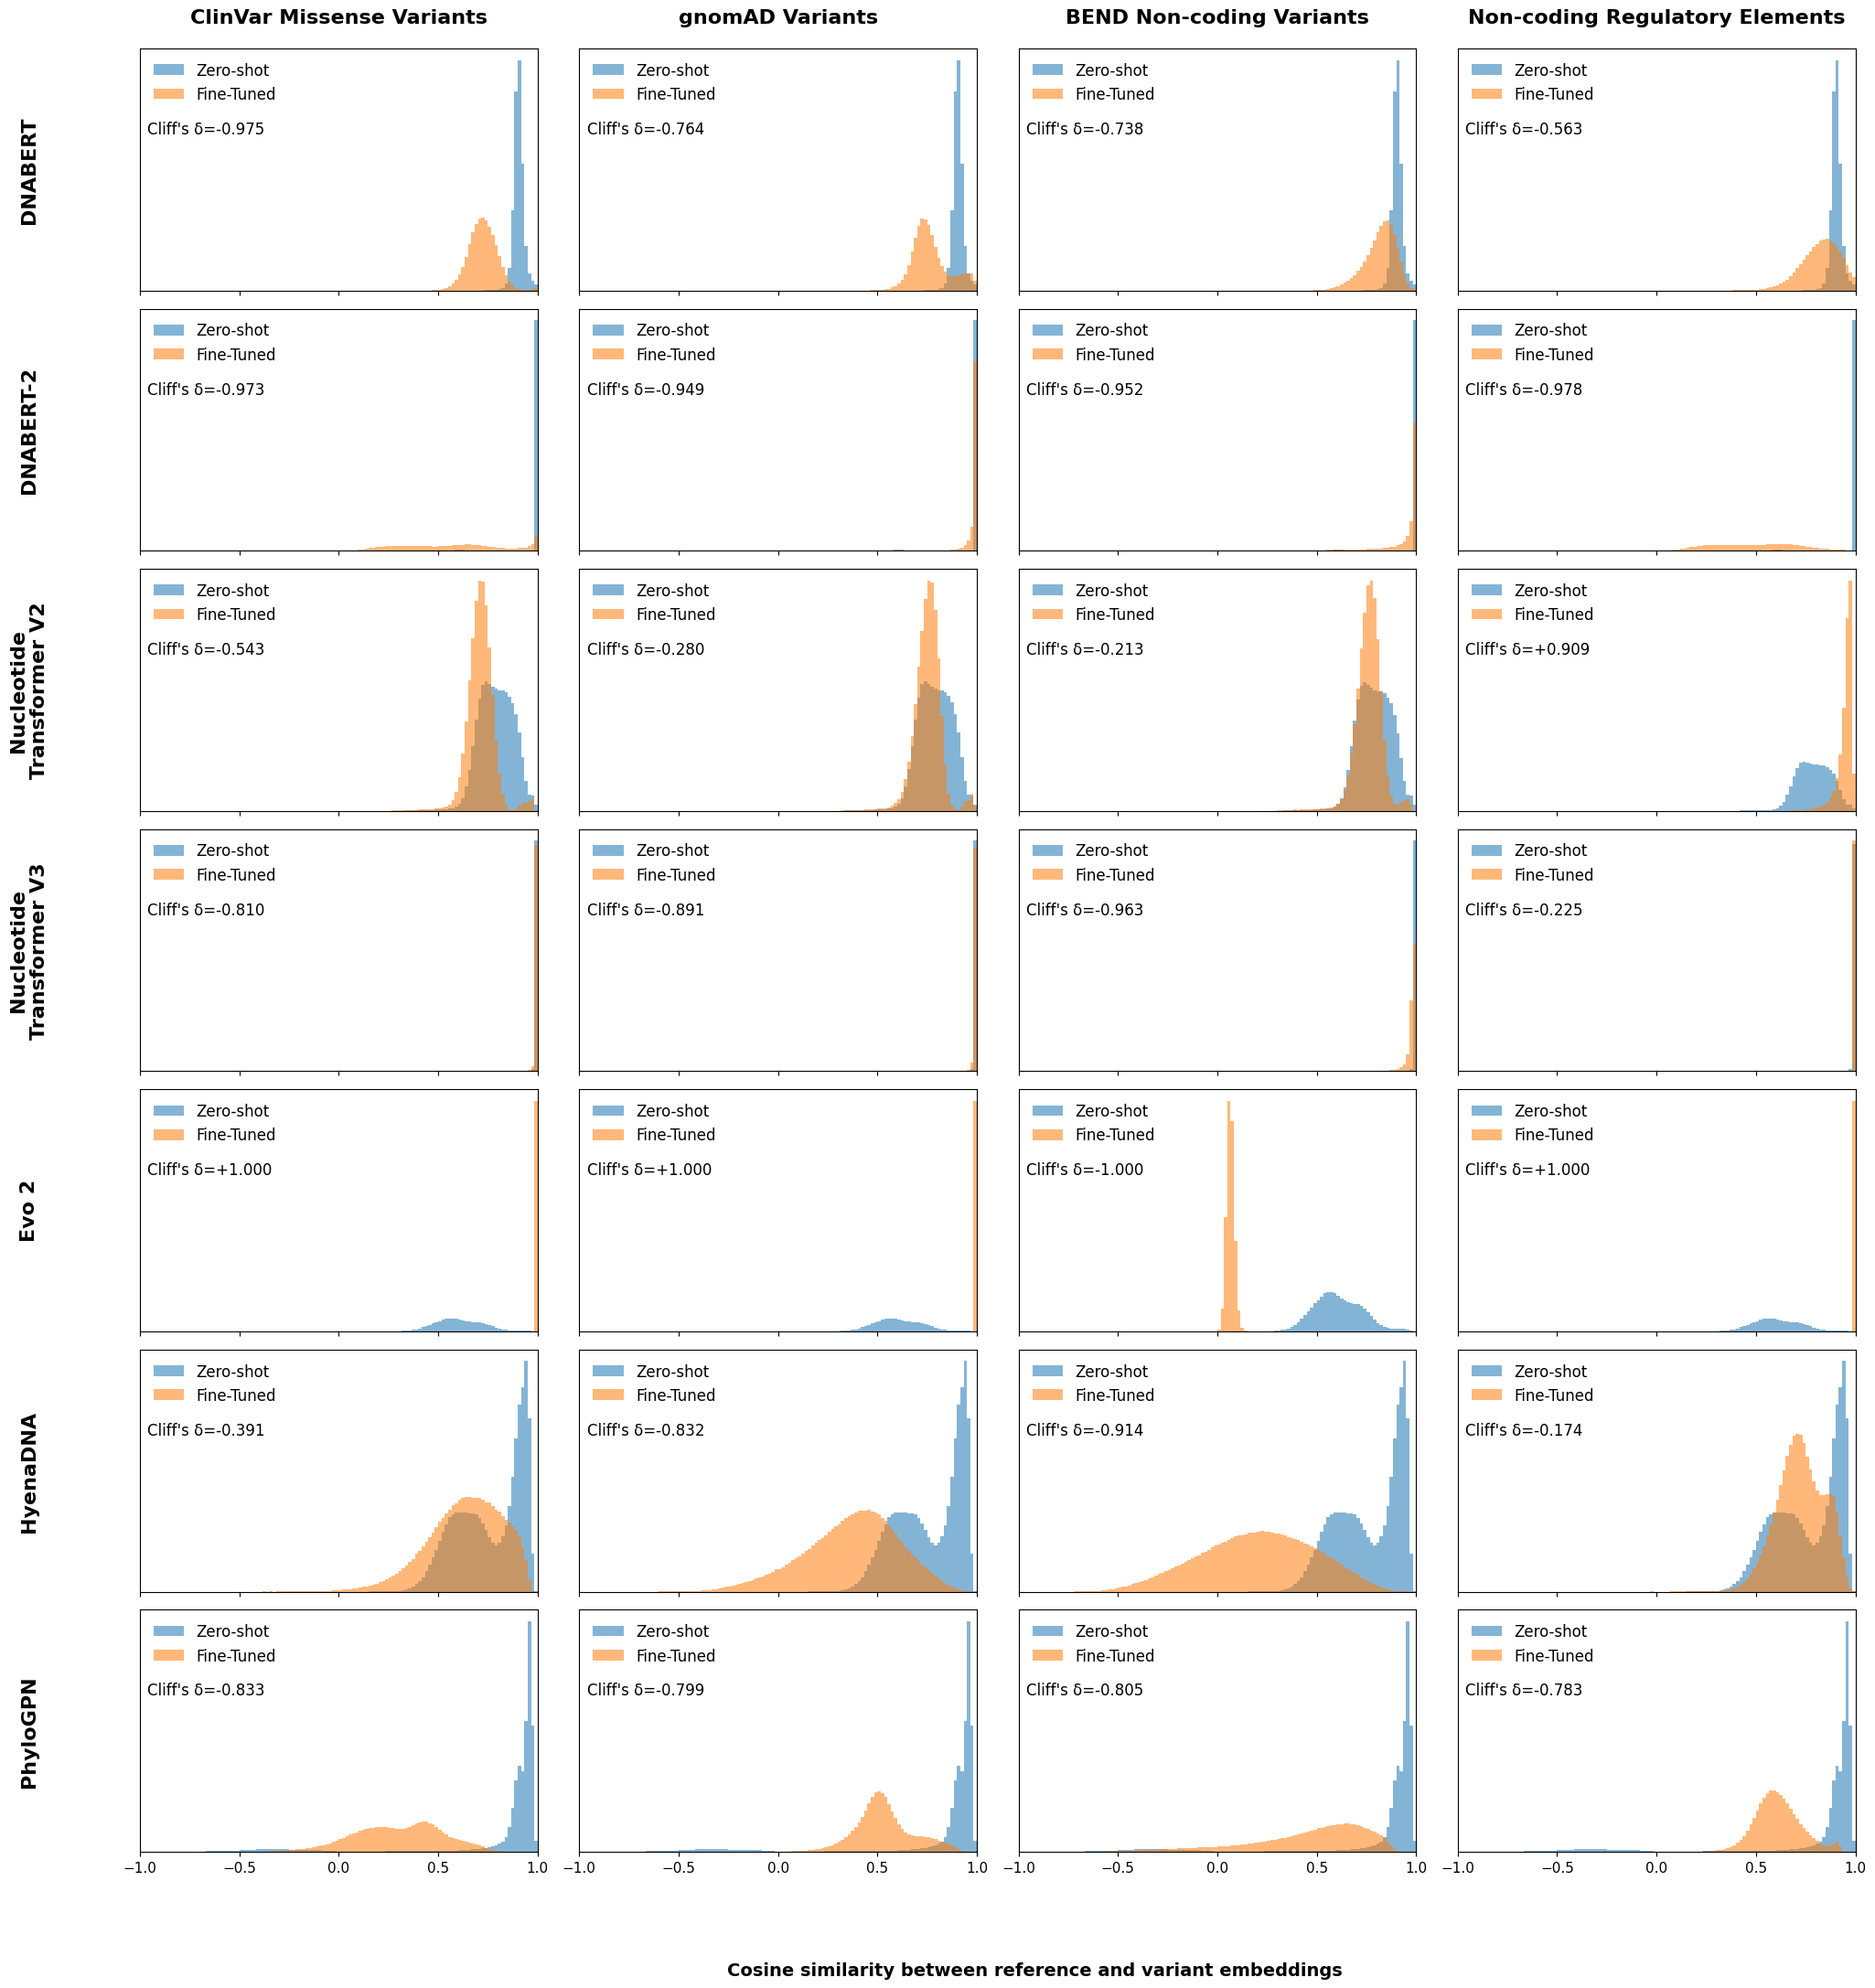

In [ ]:
def plot_distribution_grid(density=True):
    fig, axes = plt.subplots(len(MODELS), len(TASKS), figsize=(5.5*len(TASKS), 3.4*len(MODELS)), sharex=True, sharey=False)

    for r, m in enumerate(MODELS):
        for c, t in enumerate(TASKS):
            ax = axes[r, c]
            p0 = os.path.join(CACHE_DIR, f"{m}__{t}__zero.npy")
            p1 = os.path.join(CACHE_DIR, f"{m}__{t}__ft.npy")
            
            if not (os.path.exists(p0) and os.path.exists(p1)):
                ax.axis("off")
                continue
                
            cz, cf = np.load(p0).astype(float), np.load(p1).astype(float)
            mask = np.isfinite(cz) & np.isfinite(cf)
            cz, cf = cz[mask], cf[mask]

            ax.hist(cz, bins=120, range=(-1, 1), alpha=0.55, label="Zero-shot", color="tab:blue", density=density)
            ax.hist(cf, bins=120, range=(-1, 1), alpha=0.55, label="Fine-Tuned", color="tab:orange", density=density)

            ax.set_xlim(-1, 1)
            ax.set_xticks([-1.0, -0.5, 0.0, 0.5, 1.0])
            ax.tick_params(labelsize=11)
            ax.set_yticklabels([])
            ax.tick_params(axis='y', left=False)

            if r == 0:
                ax.set_title(TASK_TITLE.get(t, t), fontsize=16, fontweight="bold", pad=20)
            
            leg = ax.legend(fontsize=12, loc="upper left", frameon=False)
            cd = cliffs_delta(cf, cz)
            
            fig.canvas.draw()
            renderer = fig.canvas.get_renderer()
            bb = leg.get_window_extent(renderer).transformed(ax.transAxes.inverted())
            ax.text(bb.x0, bb.y0 - 0.05, f"Cliff's δ={cd:+.3f}", transform=ax.transAxes, ha="left", va="top", fontsize=12)

    for r, m in enumerate(MODELS):
        pos = axes[r, 0].get_position()
        fig.text(0.06, (pos.y0 + pos.y1)/2, MODEL_LABEL.get(m, m), rotation=90, ha="center", va="center", fontsize=16, fontweight="bold")

    fig.text(0.56, 0.04, "Cosine similarity between reference and variant embeddings", ha="center", fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0.1, 0.08, 0.98, 0.95])
    plt.show()

plot_distribution_grid()

# Merge cached data with variant annotations

In [ ]:
def build_merged_table():
    dnv = pd.read_feather(DNV_PATH)
    cadd_col = "CADD_phred" if "CADD_phred" in dnv.columns else [c for c in dnv.columns if "cadd" in c.lower()][0]
    dnv[cadd_col] = pd.to_numeric(dnv[cadd_col], errors="coerce")
    dnv["grp_cadd"] = np.where(dnv[cadd_col] >= 10.0, "PATHOGENIC", "BENIGN")
    
    keys_df = pd.read_feather(KEYS_FP) if os.path.exists(KEYS_FP) else dnv[["vcf_iid", "variant"]].copy()
    all_rows = []

    for m in MODELS:
        for t in TASKS:
            p0 = os.path.join(CACHE_DIR, f"{m}__{t}__zero.npy")
            p1 = os.path.join(CACHE_DIR, f"{m}__{t}__ft.npy")
            
            if os.path.exists(p0) and os.path.exists(p1):
                cz, cf = np.load(p0), np.load(p1)
                mask = np.isfinite(cz) & np.isfinite(cf)
                tmp = keys_df.iloc[np.flatnonzero(mask)].copy()
                tmp["model"], tmp["task"] = m, t
                tmp["delta_cos"] = cf[mask] - cz[mask]
                all_rows.append(tmp)

    merged = pd.concat(all_rows, ignore_index=True)
    merged = merged.merge(dnv[["vcf_iid", "variant", "grp_cadd", "most_severe_consequence"]], on=["vcf_iid", "variant"], how="inner")
    merged.to_feather(MERGED_FP)
    return merged

merged_data = build_merged_table()

# Analyze VEP impact

Generating Group A Boxplots...


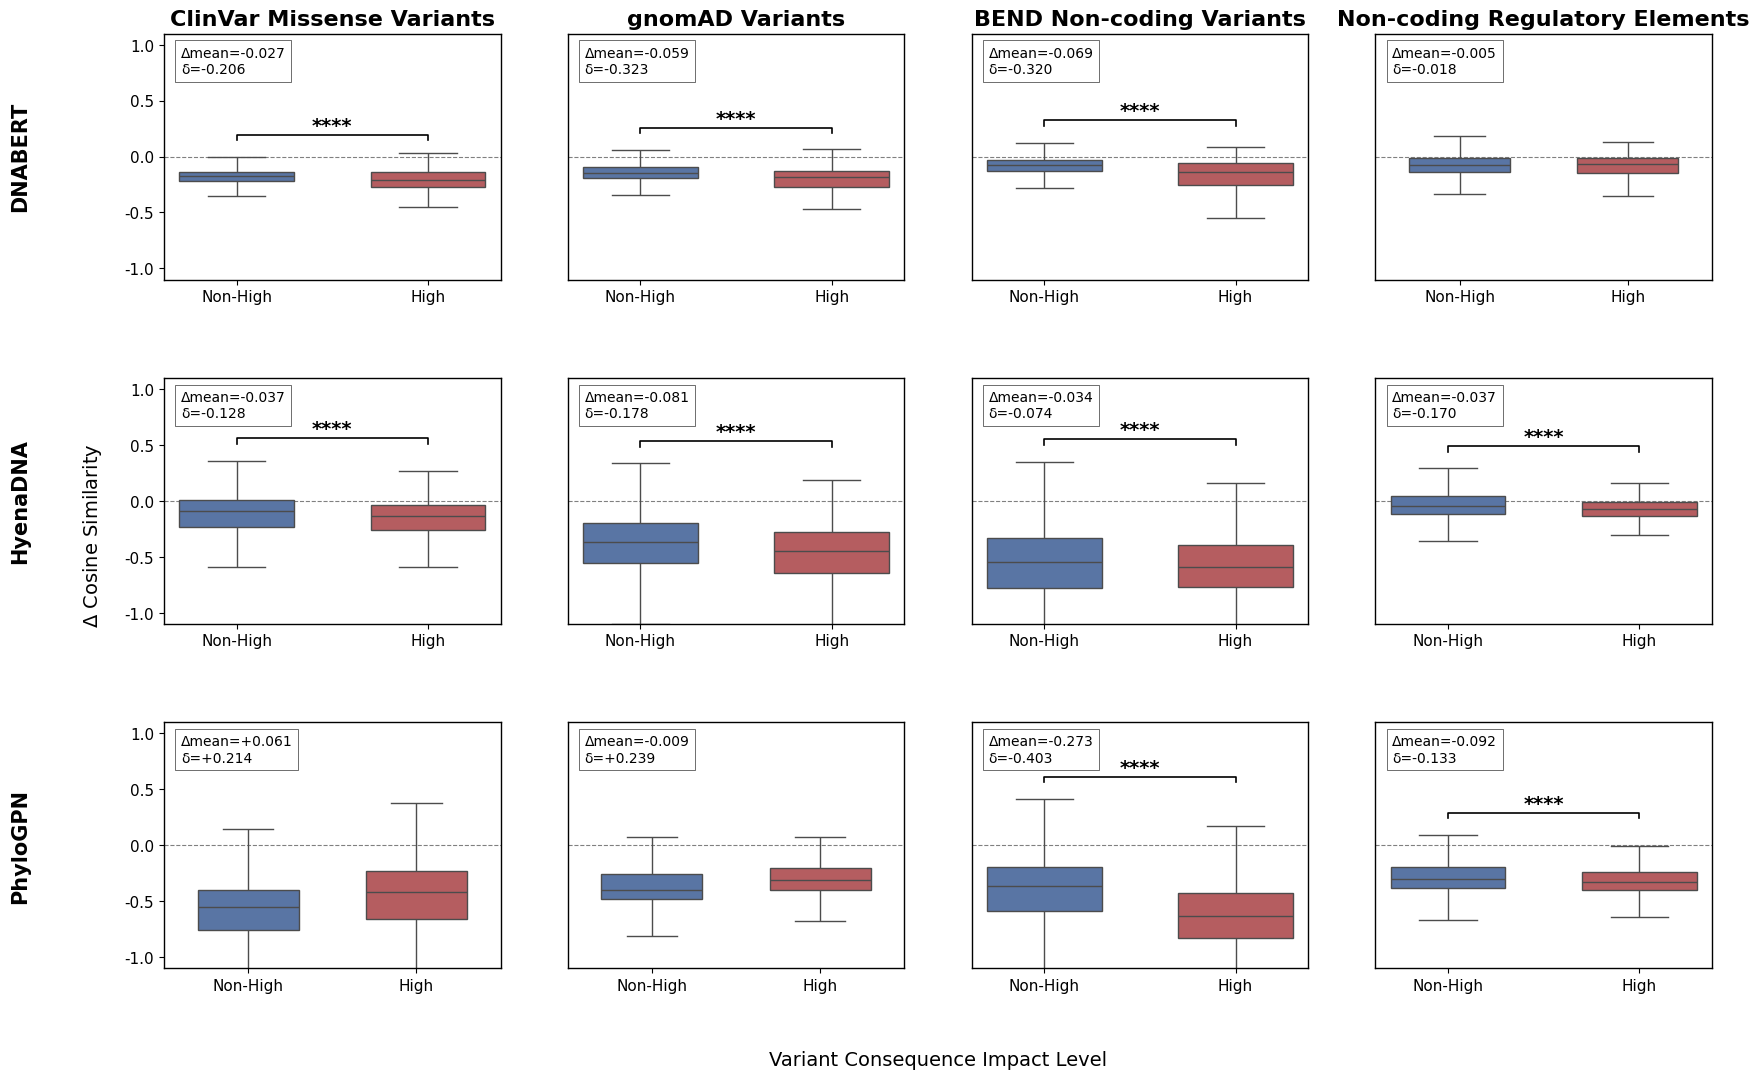

Generating Group B Boxplots...


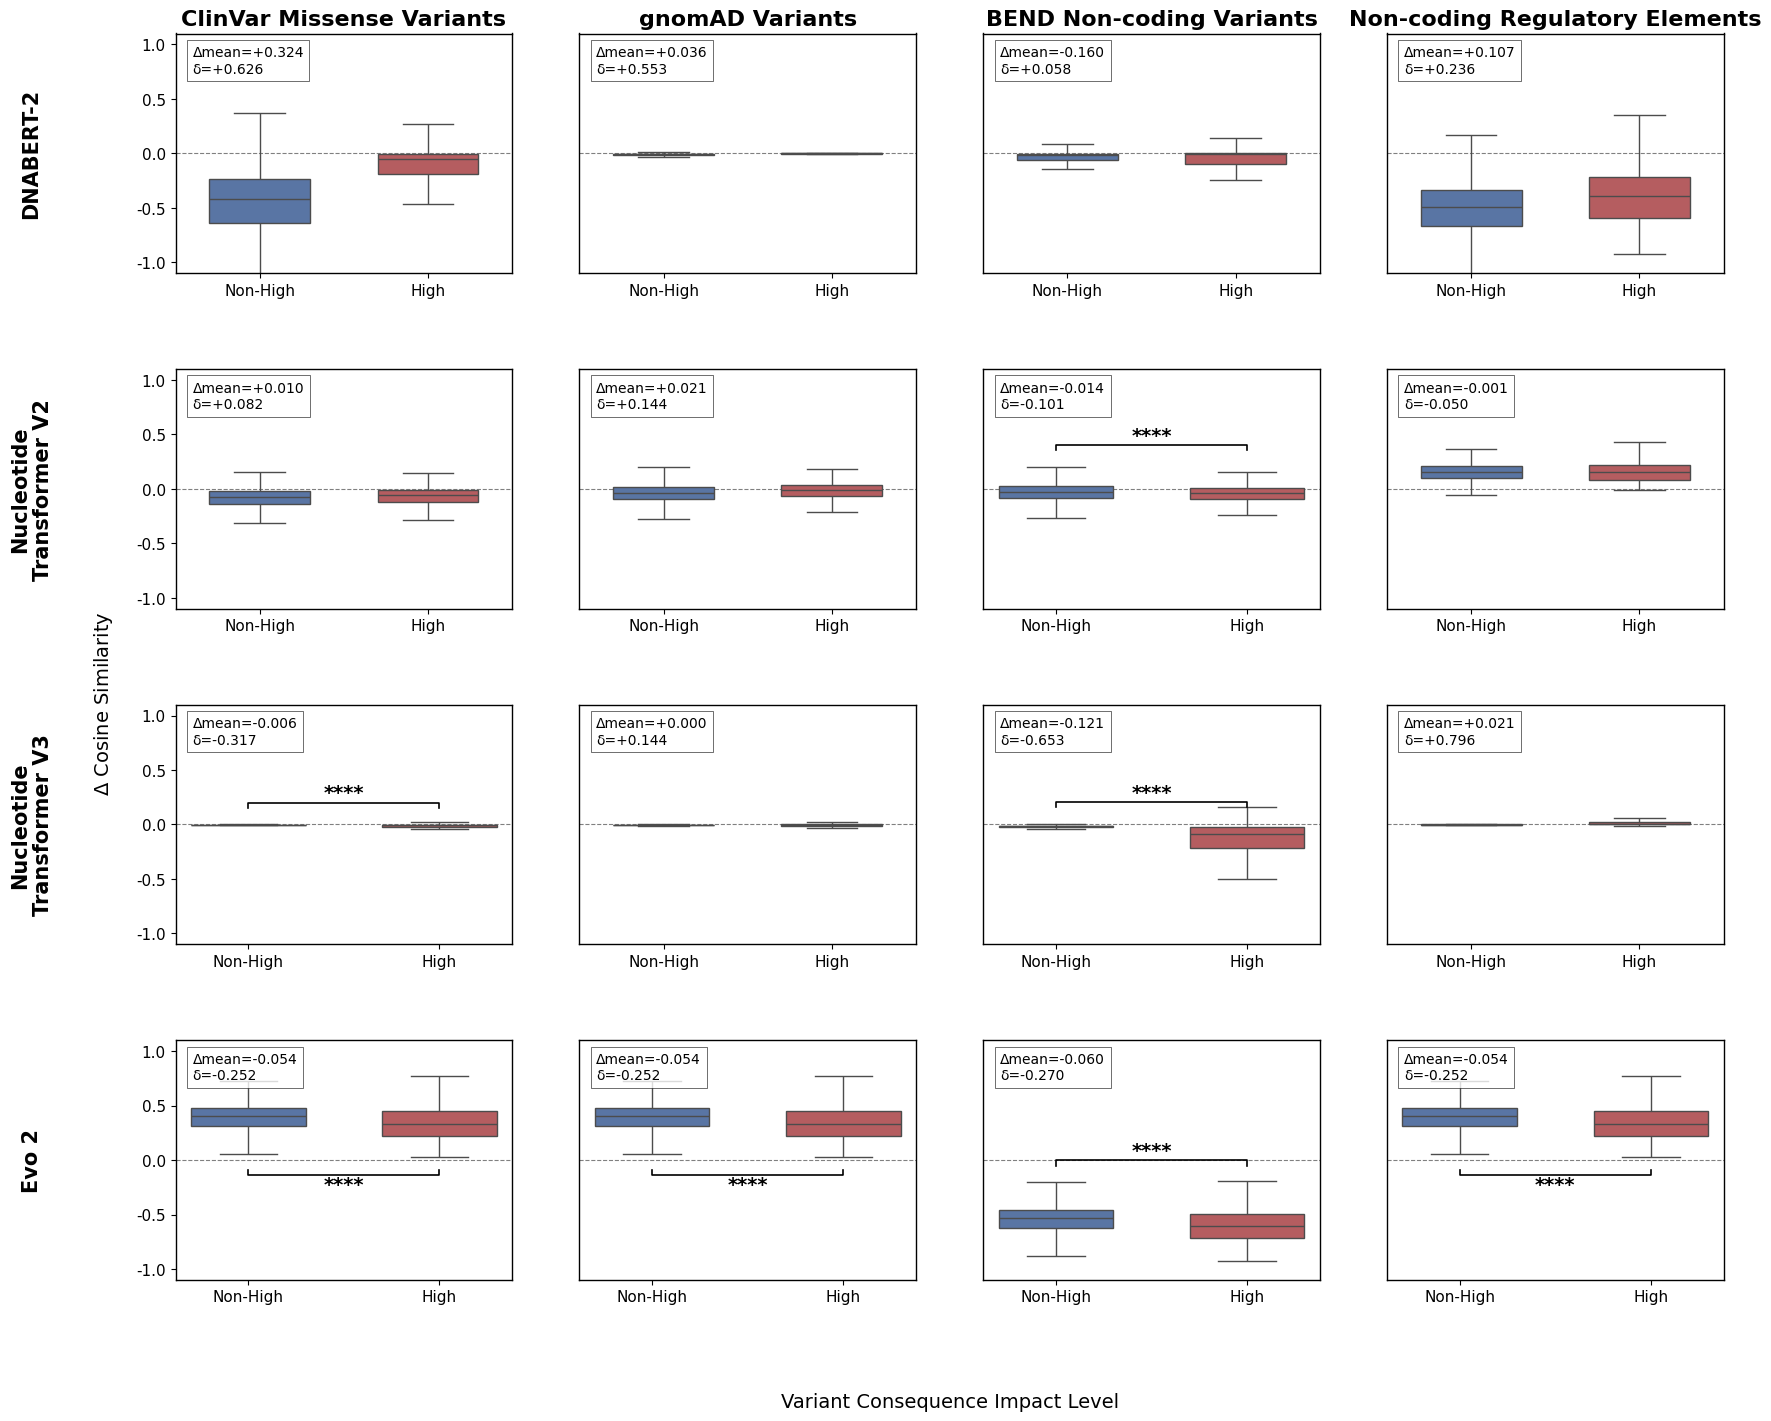

In [ ]:
def plot_vep_grid(df, models_subset):
    high_impact = ["stop_gained", "frameshift_variant", "splice_acceptor_variant", "splice_donor_variant"]
    df["grp"] = df["most_severe_consequence"].apply(lambda x: "HIGH" if x in high_impact else "NON_HIGH")
    df = df.dropna(subset=["delta_cos", "grp"])

    raw_pvals = []
    for m in models_subset:
        for t in TASKS:
            sub = df[(df["model"] == m) & (df["task"] == t)]
            h, n = sub[sub["grp"]=="HIGH"]["delta_cos"].values, sub[sub["grp"]=="NON_HIGH"]["delta_cos"].values
            raw_pvals.append(mannwhitneyu(h, n).pvalue if len(h)>1 and len(n)>1 else 1.0)
    
    _, adj_pvals, _, _ = multipletests(raw_pvals, method='bonferroni')
    p_idx = 0
    fig, axes = plt.subplots(len(models_subset), len(TASKS), figsize=(18, 4*len(models_subset)), squeeze=False)

    for r, m in enumerate(models_subset):
        for c, t in enumerate(TASKS):
            ax = axes[r, c]
            d = df[(df["model"] == m) & (df["task"] == t)]
            if d.empty:
                ax.axis("off")
                p_idx += 1; continue

            sns.boxplot(data=d, x="grp", y="delta_cos", order=["NON_HIGH", "HIGH"], hue="grp", palette={"HIGH": "#c44e52", "NON_HIGH": "#4c72b0"}, legend=False, width=0.6, showfliers=False, ax=ax)
            ax.axhline(0, ls="--", color="gray", lw=0.8)
            ax.set_ylim(-1.1, 1.1)
            ax.set_xticklabels(["Non-High", "High"])
            
            h_v, n_v = d[d["grp"]=="HIGH"]["delta_cos"].values, d[d["grp"]=="NON_HIGH"]["delta_cos"].values
            cd, dm = cliffs_delta(h_v, n_v), np.mean(h_v) - np.mean(n_v)
            ax.text(0.05, 0.95, f"Δmean={dm:+.3f}\nδ={cd:+.3f}", transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.8, lw=0.5))

            star = p_to_star(adj_pvals[p_idx])
            if star != "n.s." and cd < 0: add_sig_bracket(ax, 0, 1, 0.8, 0.05, star)
            p_idx += 1

    plt.tight_layout()
    plt.show()

plot_vep_grid(merged_data, MODELS)

# Analyze CADD score impact

[INFO] Table built with 19735128 variants.
--- Group A Boxplots ---


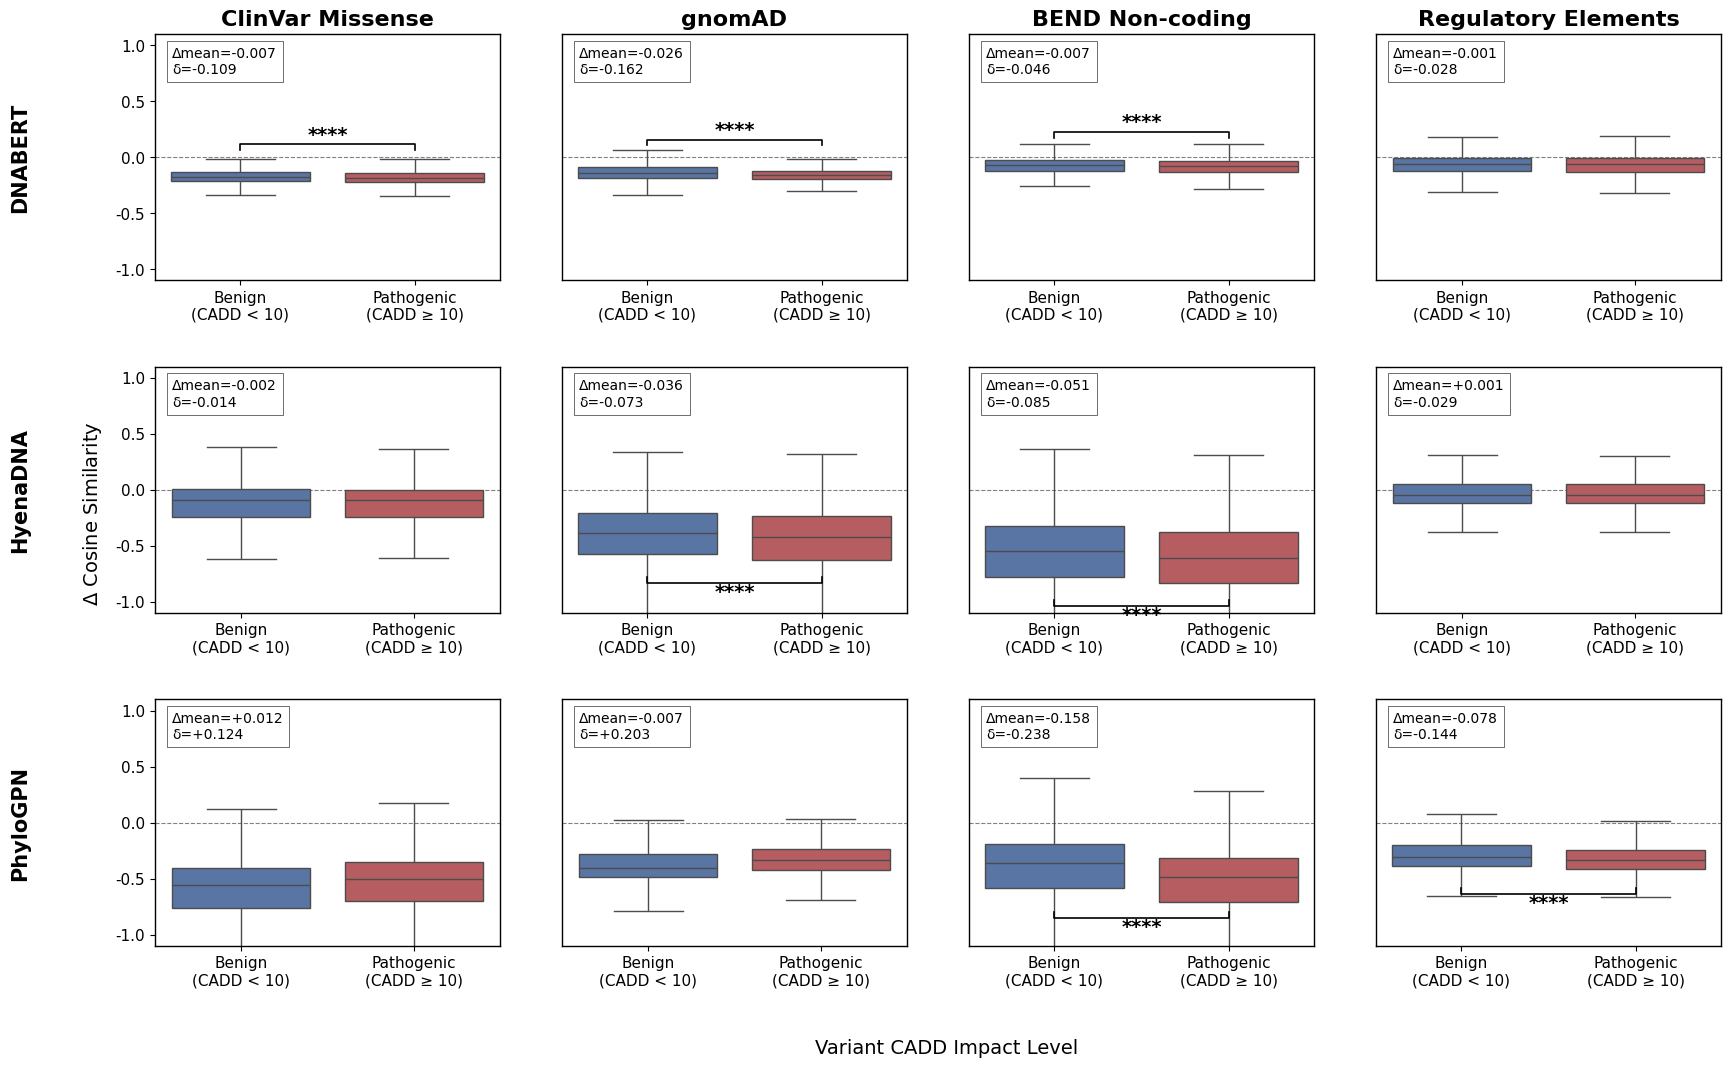

--- Group B Boxplots ---


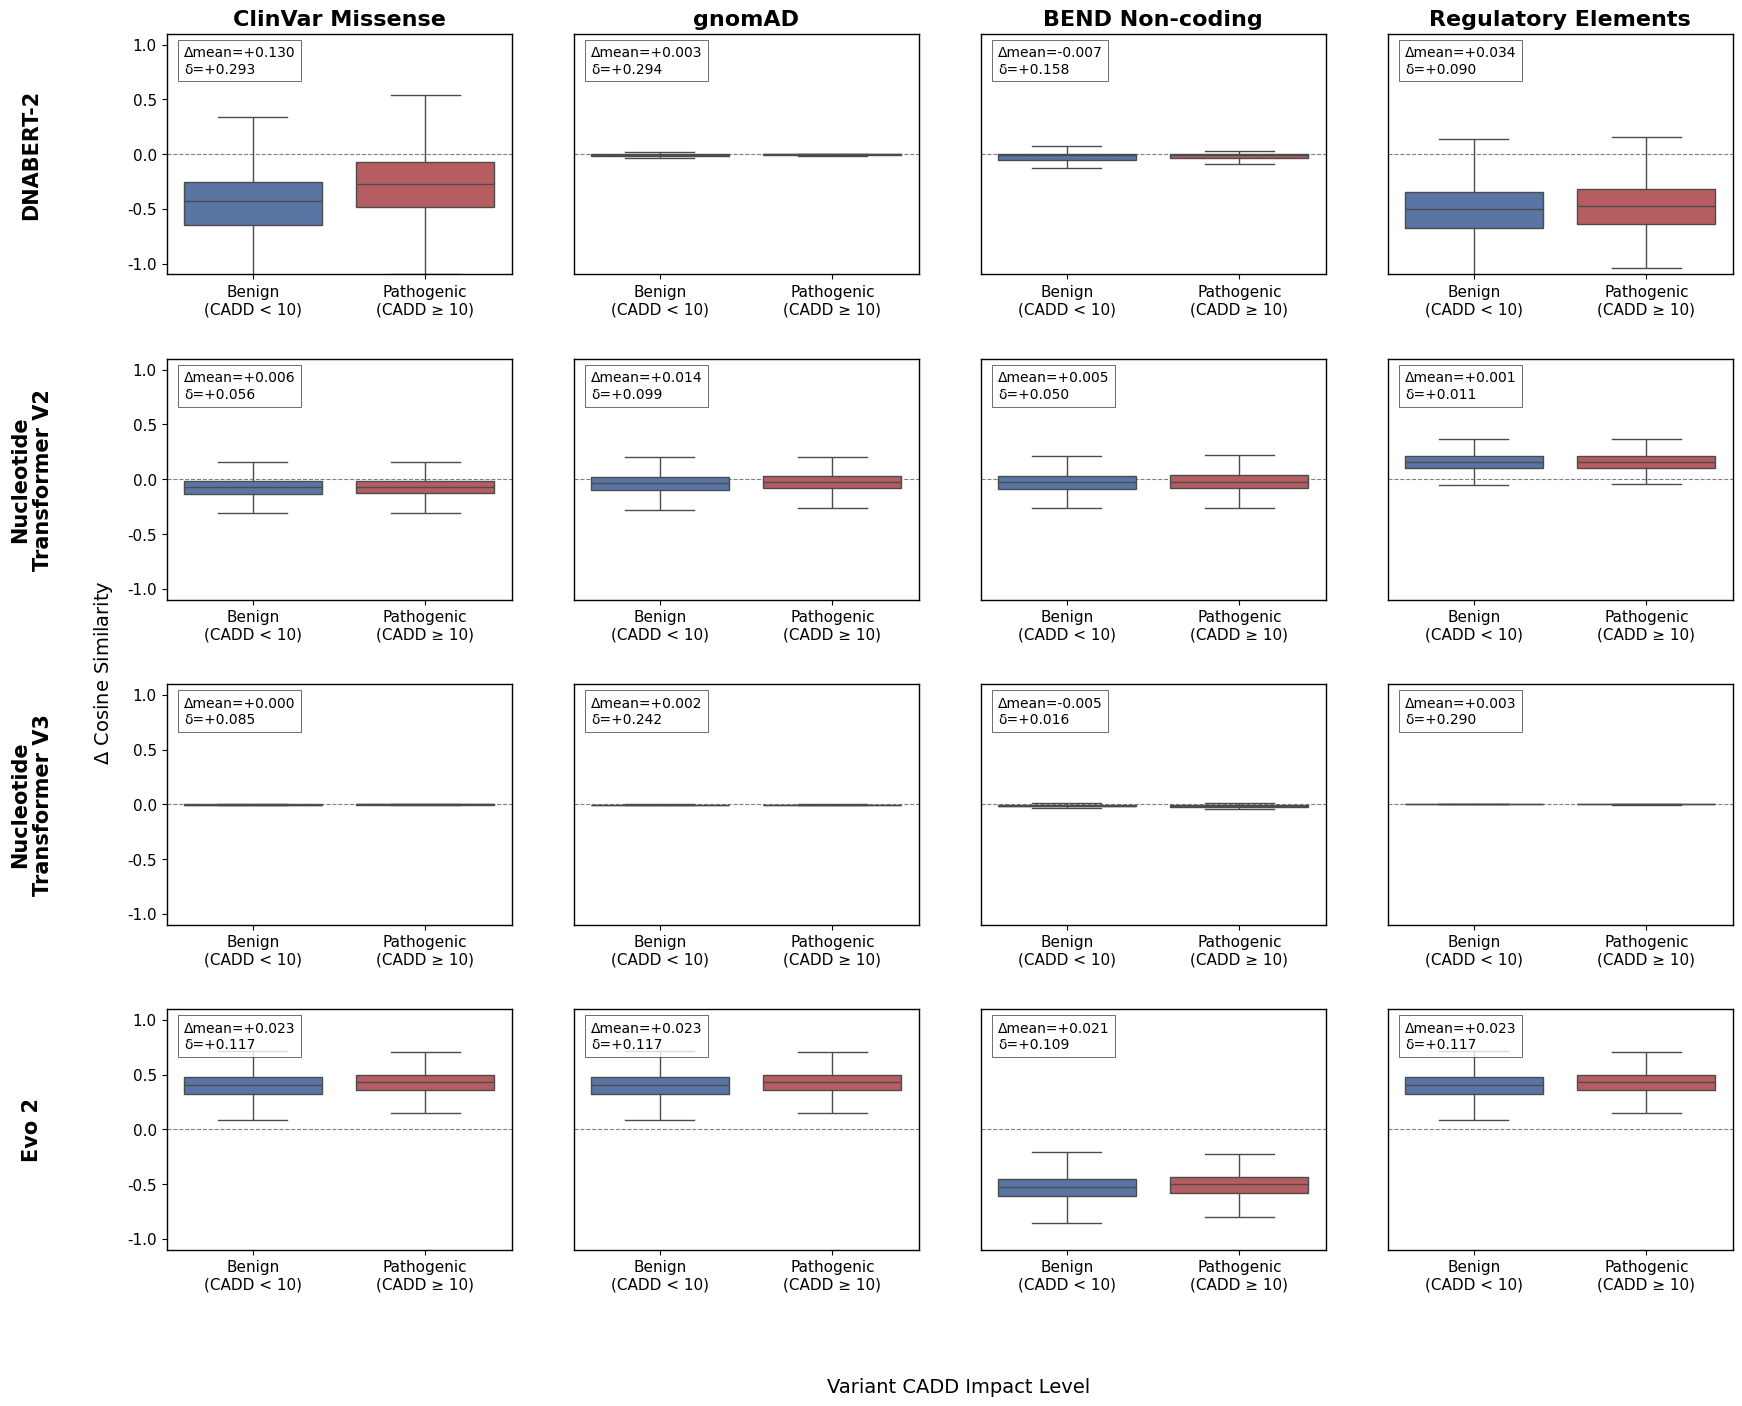

In [ ]:
def plot_cadd_grid(df, models_subset):
    raw_pvals = []
    for m in models_subset:
        for t in TASKS:
            sub = df[(df["model"] == m) & (df["task"] == t)]
            p = mannwhitneyu(sub[sub["grp_cadd"]=="PATHOGENIC"]["delta_cos"], sub[sub["grp_cadd"]=="BENIGN"]["delta_cos"]).pvalue if len(sub)>0 else 1.0
            raw_pvals.append(p)
    _, adj_pvals, _, _ = multipletests(raw_pvals, method='bonferroni')

    p_idx = 0
    fig, axes = plt.subplots(len(models_subset), len(TASKS), figsize=(18, 4*len(models_subset)), squeeze=False)

    for r, m in enumerate(models_subset):
        for c, t in enumerate(TASKS):
            ax = axes[r, c]
            sub = df[(df["model"] == m) & (df["task"] == t)].dropna(subset=["delta_cos", "grp_cadd"])
            if sub.empty:
                ax.axis("off")
                p_idx += 1; continue

            sns.boxplot(data=sub, x="grp_cadd", y="delta_cos", order=["BENIGN", "PATHOGENIC"], hue="grp_cadd", palette={"PATHOGENIC": "#c44e52", "BENIGN": "#4c72b0"}, showfliers=False, ax=ax, legend=False, width=0.6)
            ax.axhline(0, ls="--", color="gray", lw=0.8)
            ax.set_ylim(-1.1, 1.1)
            ax.set_xticklabels(["Benign", "Pathogenic"])

            h_v, n_v = sub[sub["grp_cadd"]=="PATHOGENIC"]["delta_cos"].values, sub[sub["grp_cadd"]=="BENIGN"]["delta_cos"].values
            cd, dm = cliffs_delta(h_v, n_v), np.mean(h_v) - np.mean(n_v)
            ax.text(0.05, 0.95, f"Δmean={dm:+.3f}\nδ={cd:+.3f}", transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7, lw=0.5))

            star = p_to_star(adj_pvals[p_idx])
            if star != "n.s." and cd < 0: add_sig_bracket(ax, 0, 1, 0.8, 0.05, star)
            p_idx += 1

    plt.tight_layout()
    plt.show()

plot_cadd_grid(merged_data, MODELS)